In [1]:
from __future__ import print_function, division
import mdtraj as md
from mdtraj.utils import ensure_type
from mdtraj.geometry import compute_distances, compute_angles
from mdtraj.geometry import _geometry
import os
import sys
import numpy as np
import scipy as sp
from scipy import optimize
from scipy.optimize import leastsq
import matplotlib.pyplot as plt
from matplotlib import colors
import seaborn as sns
import math
import itertools    
from numpy import log2, zeros, mean, var, sum, loadtxt, arange, array, cumsum, dot, transpose, diagonal, floor
from numpy.linalg import inv, lstsq
import pyblock
from mdtraj.geometry import _geometry
from mdtraj.utils import ensure_type
from mdtraj.geometry import compute_distances, compute_angles
from scipy.stats import pearsonr
import json

class NpEncoder(json.JSONEncoder):
    def default(self, obj):
        if isinstance(obj, np.integer):
            return int(obj)
        if isinstance(obj, np.floating):
            return float(obj)
        if isinstance(obj, np.ndarray):
            return obj.tolist()
        return json.JSONEncoder.default(self, obj)

In [2]:
def subplot_snsheat(data, ax=None, cbar=False, cbar_ax=None):
    from numpy import ndarray
    import seaborn as sns
    if type(data) is ndarray:

        if ax is None:
            ax = plt.gca()

        plot = sns.heatmap(data, cmap='jet', vmin=0,vmax=0.5,ax=ax, cbar=cbar, cbar_ax=None if not cbar else cbar_ax)
        return plot

    else: pass
    
def subplot_imshow(data, xedges, yedges, ax=None):
    
    from numpy import ndarray
    
    if type(data) is ndarray:

        if ax is None:
            ax = plt.gca()
            
        im = ax.imshow(data, interpolation='gaussian', extent=[yedges[0], yedges[-1], xedges[0], xedges[-1]],
                        cmap='jet', aspect='auto')
        #cb = plt.colorbar(ticks=cbar_ticks, format=('% .1f'),aspect=10)
        
        return im
    
    else : pass

In [3]:
dir = os.getcwd()
outdir = os.path.join(dir, 'plots/')
if not os.path.exists(outdir):
    os.makedirs(outdir)

In [4]:
dir

'/Users/kaushikborthakur1211/Desktop/p27/New_2025_runs/kappa_tests/mutants/W76A/apo/xtc_files'

In [7]:
pdb = os.path.join(dir,'prot.pdb')
trajectory = os.path.join(dir,'rep.0.xtc')
pdb = md.load_pdb(pdb)
protein_indices = pdb.topology.select('protein')
trajectory = md.load_xtc(trajectory, top=pdb.topology, atom_indices=protein_indices)

In [8]:
trj = trajectory
trj.center_coordinates()
# trj = trj[1:]
top = trj.topology
first_frame = 0
last_frame = trj.n_frames
n_frames=trj.n_frames

nres=[]
for res in trj.topology.residues: nres.append(res.resSeq)
sequence=(' %s' % [residue for residue in trj.topology.residues])
resname=(' %s' % [residue.name for residue in trj.topology.residues])
resindex=(' %s' % [residue.index for residue in trj.topology.residues])
prot_top=top.subset(top.select('protein'))
prot_res=[]
for res in prot_top.residues: prot_res.append(res.resSeq)
prot_resname=(' %s' % [residue.name for residue in prot_top.residues])
residues=len(set(prot_res))

print("** SYSTEM INFO **\n")
print("Number of atoms: %d\n" % trj.n_atoms)
print("Number of residues: %d\n" % len(set(nres)))
print("Number of protein residues: %d\n" % len(set(prot_res)))
print("Number of frames: %d\n" % trj.n_frames)
print("Starting frame: %d\n" % first_frame)
print("Last frame: %d\n" % last_frame)
print("sequence: %s\n" % sequence)
print("residue names: %s\n" % resname)
print("residue index: %s\n" % resindex)

** SYSTEM INFO **

Number of atoms: 793

Number of residues: 48

Number of protein residues: 48

Number of frames: 45917

Starting frame: 0

Last frame: 45917

sequence:  [ARG58, LYS59, TRP60, ASN61, PHE62, ASP63, PHE64, GLN65, ASN66, HIS67, LYS68, PRO69, LEU70, GLU71, GLY72, LYS73, TYR74, GLU75, ALA76, GLN77, GLU78, VAL79, GLU80, LYS81, GLY82, SER83, LEU84, PRO85, GLU86, PHE87, TYR88, TYR89, ARG90, PRO91, PRO92, ARG93, PRO94, PRO95, LYS96, GLY97, ALA98, CYS99, LYS100, VAL101, PRO102, ALA103, GLN104, GLU105]

residue names:  ['ARG', 'LYS', 'TRP', 'ASN', 'PHE', 'ASP', 'PHE', 'GLN', 'ASN', 'HIS', 'LYS', 'PRO', 'LEU', 'GLU', 'GLY', 'LYS', 'TYR', 'GLU', 'ALA', 'GLN', 'GLU', 'VAL', 'GLU', 'LYS', 'GLY', 'SER', 'LEU', 'PRO', 'GLU', 'PHE', 'TYR', 'TYR', 'ARG', 'PRO', 'PRO', 'ARG', 'PRO', 'PRO', 'LYS', 'GLY', 'ALA', 'CYS', 'LYS', 'VAL', 'PRO', 'ALA', 'GLN', 'GLU']

residue index:  [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 

In [9]:
full_sequence=[]
for residue in trj.topology.residues:
    full_sequence.append(residue)

full_sequence = [str(residue) for residue in full_sequence]

single_letter_code = {
    'ALA': 'A', 'ARG': 'R', 'ASN': 'N', 'ASP': 'D', 'CYS': 'C',
    'GLU': 'E', 'GLN': 'Q', 'GLY': 'G', 'HIS': 'H', 'ILE': 'I',
    'LEU': 'L', 'LYS': 'K', 'MET': 'M', 'PHE': 'F', 'PRO': 'P',
    'SER': 'S', 'THR': 'T', 'TRP': 'W', 'TYR': 'Y', 'VAL': 'V'
}

single_letter_sequence = [single_letter_code[res[:3]] + res[3:] for res in full_sequence]

sequence=[]
for residue in trj.topology.residues:
    sequence.append(str(residue))
len(sequence)

n=5
for i in range (0,len(sequence)):
  if (i % n !=0):
   sequence[i]=''

print(sequence)

['ARG58', '', '', '', '', 'ASP63', '', '', '', '', 'LYS68', '', '', '', '', 'LYS73', '', '', '', '', 'GLU78', '', '', '', '', 'SER83', '', '', '', '', 'TYR88', '', '', '', '', 'ARG93', '', '', '', '', 'ALA98', '', '', '', '', 'ALA103', '', '']


In [10]:
replica0, nrep = 0,20
rep0, nrep = 0,20

temperature = np.array([
    300.0, 304.6, 309.2, 313.9, 318.7,
    323.6, 328.5, 333.5, 338.6, 343.8,
    349.0, 354.4, 359.8, 365.3, 370.8,
    376.5, 382.2, 388.1, 394.0, 400.0
])

In [11]:
contact_map_p=json.load(open(dir+'/out_d/p_contact_map.json','r'))

In [12]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
import os

def create_subplots(keys, filename, title_prefix):
    nrep = len(keys)
    ncol = 4
    nrow = int(np.ceil(nrep / ncol))

    # Let Matplotlib manage layout and reserve space for the colorbar
    fig, axes = plt.subplots(nrow, ncol, sharex=True, sharey=True,
                             figsize=(12, 12), constrained_layout=True)
    axes = np.array(axes).reshape(nrow, ncol).flatten()

    # (Optional) fix color scale across all maps
    # If your contact maps are probabilities, this is appropriate:
    norm = Normalize(vmin=0.0, vmax=1.0)

    for i, key in enumerate(keys):
        if i >= len(axes): break
        ax = axes[i]
        contact_map = contact_map_p[key]
        sns.heatmap(contact_map, ax=ax, cmap='jet', cbar=False,
                    vmin=norm.vmin, vmax=norm.vmax)

        ax.set_xticks(range(48))
        ax.set_xticklabels(sequence, rotation=90, size=8)
        ax.set_yticks(range(48))
        ax.set_yticklabels(sequence, rotation=0, size=8)
        ax.invert_yaxis()
        ax.set_title(f'{title_prefix}-{i}', size=12, pad=3)

    # Hide any unused axes if nrep isn't multiple of ncol
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    # One shared, full-height colorbar; constrained_layout will make room
    sm = plt.cm.ScalarMappable(cmap='jet', norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=axes, location='right', shrink=1.0, aspect=30)
    cbar.set_label('Contact Probability', fontsize=12)

    filepath = os.path.join(outdir, filename)
    plt.savefig(filepath, dpi=600)   # no bbox_inches='tight' needed
    plt.show()


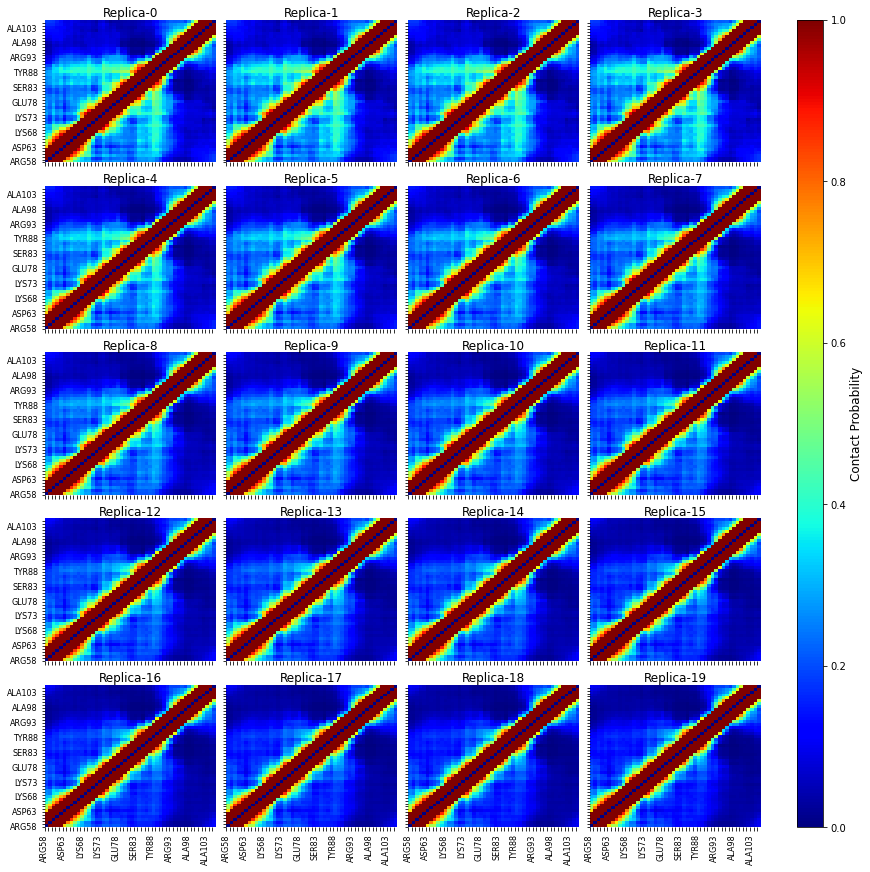

In [13]:

rep_keys = [f'rep:{i}' for i in range(20)]
create_subplots(rep_keys, outdir+'p_contact_maps_rep.png', 'Replica')

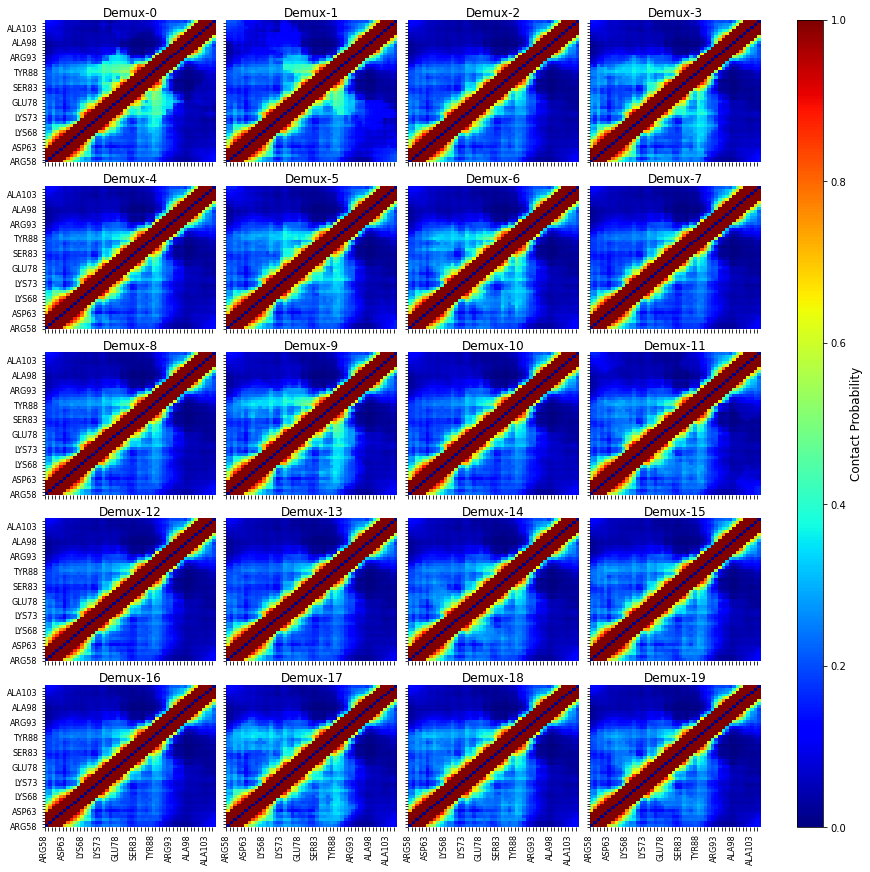

In [14]:
demux_keys = [f'demux:{i}' for i in range(20)]
create_subplots(demux_keys, outdir+'p_contact_maps_demux.png', 'Demux')

In [15]:
hc=json.load(open(dir+'/out_d/helix_contant.json','r'))
bsc=json.load(open(dir+'/out_d/sheet_contant.json','r'))
sa=json.load(open(dir+'/out_d/sa.json','r'))
rg=json.load(open(dir+'/out_d/rg.json','r'))

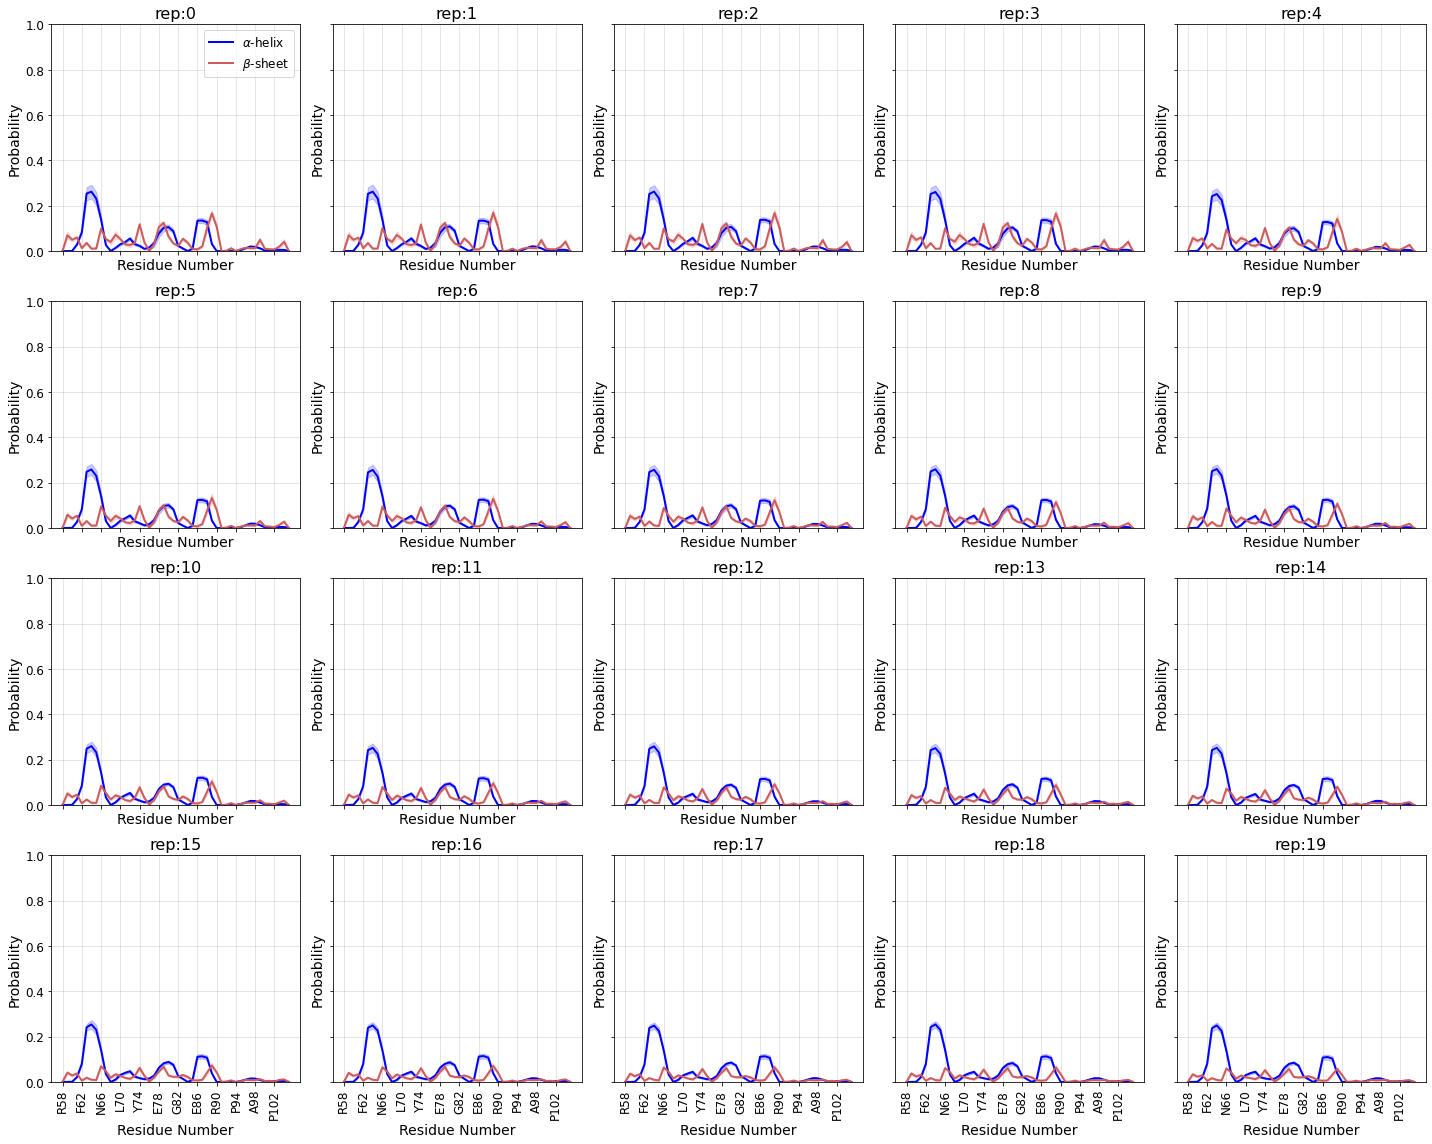

In [16]:
import numpy as np
import matplotlib.pyplot as plt

# Filter dictionaries to include only keys that start with 'rep:'
hc_replica = {key: hc[key] for key in hc if key.startswith('rep:')}
bsc_replica = {key: bsc[key] for key in bsc if key.startswith('rep:')}

# Extract keys for replicas
keys = list(hc_replica.keys())

# Determine number of columns and rows for subplots
ncol = 5
nrow = 4  # Adjust for number of items to plot

fig, ax = plt.subplots(nrow, ncol, sharex=True, sharey=True, figsize=(20, 16))
fig.subplots_adjust(hspace=0.5, wspace=0.2)  # Adjust spacing between subplots

ax[0, 0].set_ylim(0, 1.0)
# Define the spacing for x-ticks
n = 4  # Adjust this value to control the spacing of the x-ticks

for i, key in enumerate(keys):
    data_hc = np.array(hc_replica.get(key, np.zeros((48, 2))))  # Convert to numpy array
    data_bsc = np.array(bsc_replica.get(key, np.zeros((48, 2))))  # Convert to numpy array
    p, q = divmod(i, ncol)
    
    # Extracting data for helix content
    residues_hc = np.arange(1, 49)  # Assuming residues are from 1 to 48
    helix_content = data_hc[:, 0]
    helix_error = data_hc[:, 1]

    # Extracting data for beta sheet content
    residues_bsc = np.arange(1, 49)  # Assuming residues are from 1 to 48
    sheet_content = data_bsc[:, 0]
    sheet_error = data_bsc[:, 1]

    # Plotting helix content
    ax[p, q].plot(residues_hc, helix_content, linestyle='-', color='b', lw=2, label=r'$\alpha$-helix')
    ax[p, q].fill_between(residues_hc, helix_content - helix_error, helix_content + helix_error, color='b', alpha=0.2)

    # Plotting beta sheet content
    ax[p, q].plot(residues_bsc, sheet_content, linestyle='-', color='indianred', lw=2, label=r'$\beta$-sheet')
    ax[p, q].fill_between(residues_bsc, sheet_content - sheet_error, sheet_content + sheet_error, color='indianred', alpha=0.2)

    # Set plot properties
    ax[p, q].set_title(f'{key}', size=16)
    ax[p, q].set_xlabel('Residue Number', size=14)
    ax[p, q].set_ylabel('Probability', size=14)
    ax[p, q].grid(alpha=0.4)
    ax[p, q].tick_params(axis='both', which='major', labelsize=12)
    
    # Set spaced x-ticks to full sequence in the last four plots
    if p == nrow - 1:  # Only for the last row of plots
        spaced_ticks = residues_hc[::n]
        spaced_labels = single_letter_sequence[::n]
        ax[p, q].set_xticks(spaced_ticks)
        ax[p, q].set_xticklabels(spaced_labels, rotation=90, fontsize=12)
    else:
        ax[p, q].set_xticks([])

# Add legend to the first plot (ax[0, 0])
ax[0, 0].legend(loc='upper right', fontsize=12)

# Adjust layout and save/show plot
plt.tight_layout()
plt.savefig(outdir+'secondary_structure_subplot_replicas.png', dpi=800)
plt.show()


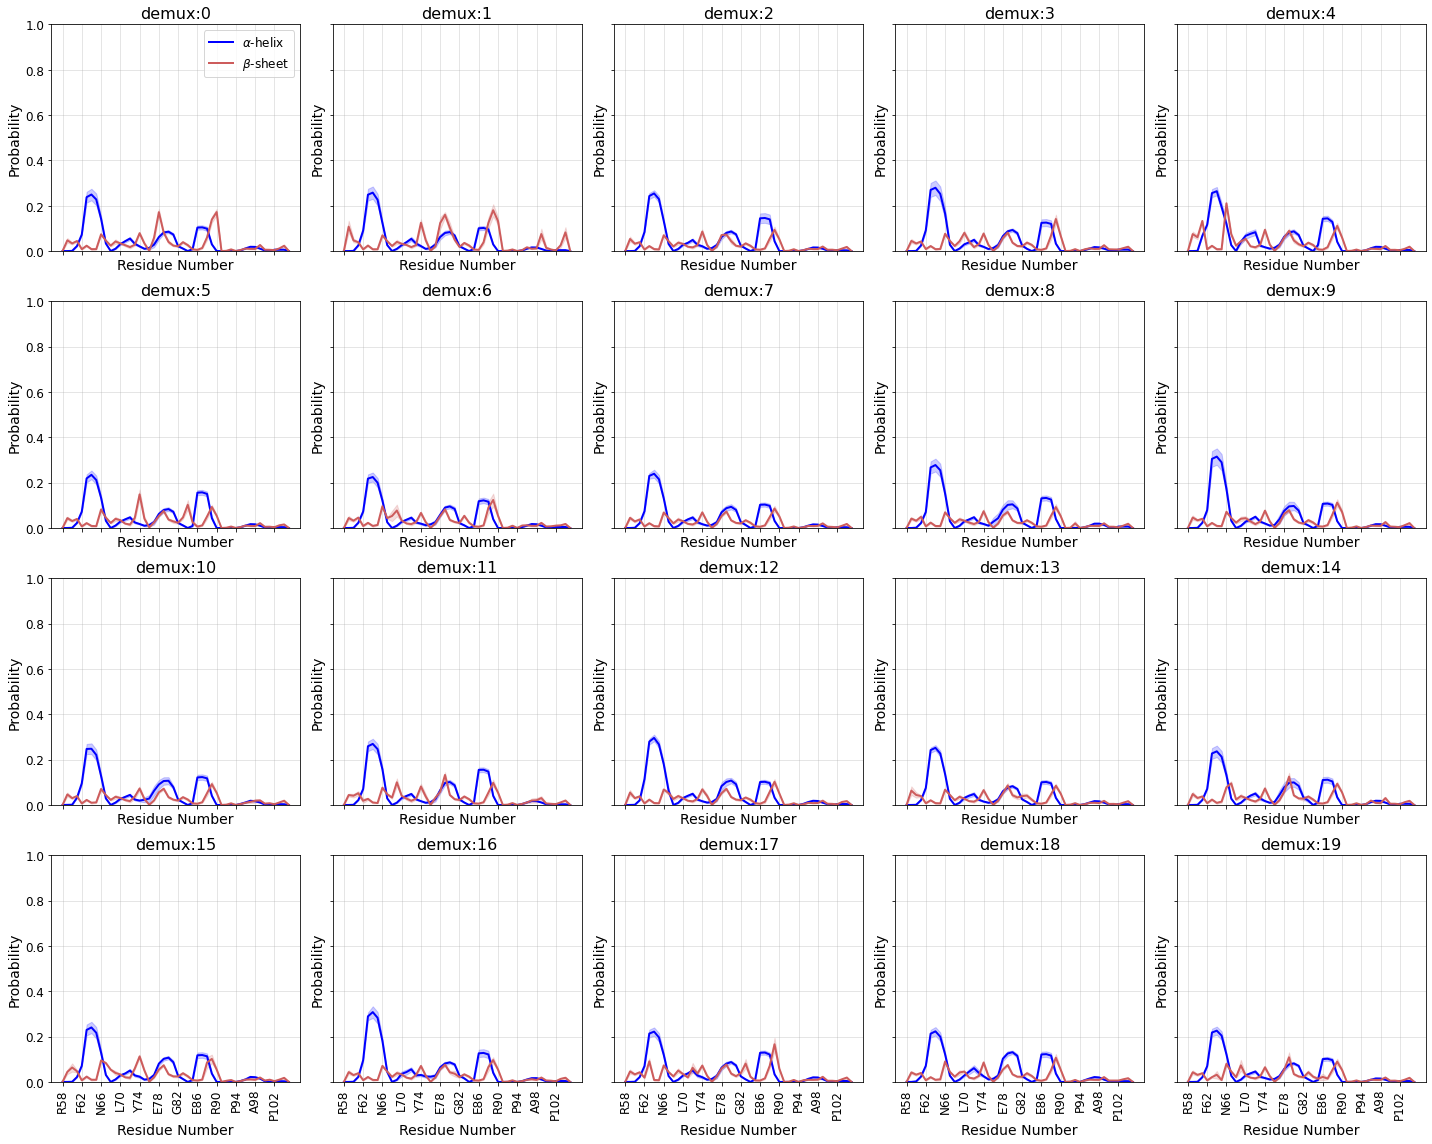

In [17]:
import numpy as np
import matplotlib.pyplot as plt

# Filter dictionaries to include only keys that start with 'rep:'
hc_replica = {key: hc[key] for key in hc if key.startswith('demux:')}
bsc_replica = {key: bsc[key] for key in bsc if key.startswith('demux:')}

# Extract keys for replicas
keys = list(hc_replica.keys())

# Determine number of columns and rows for subplots
ncol = 5
nrow = 4  # Adjust for number of items to plot

fig, ax = plt.subplots(nrow, ncol, sharex=True, sharey=True, figsize=(20, 16))
fig.subplots_adjust(hspace=0.5, wspace=0.2)  # Adjust spacing between subplots

ax[0, 0].set_ylim(0, 1.0)

# Define the spacing for x-ticks
n = 4  # Adjust this value to control the spacing of the x-ticks

for i, key in enumerate(keys):
    data_hc = np.array(hc_replica.get(key, np.zeros((48, 2))))  # Convert to numpy array
    data_bsc = np.array(bsc_replica.get(key, np.zeros((48, 2))))  # Convert to numpy array
    p, q = divmod(i, ncol)
    
    # Extracting data for helix content
    residues_hc = np.arange(1, 49)  # Assuming residues are from 1 to 48
    helix_content = data_hc[:, 0]
    helix_error = data_hc[:, 1]

    # Extracting data for beta sheet content
    residues_bsc = np.arange(1, 49)  # Assuming residues are from 1 to 48
    sheet_content = data_bsc[:, 0]
    sheet_error = data_bsc[:, 1]

    # Plotting helix content
    ax[p, q].plot(residues_hc, helix_content, linestyle='-', color='b', lw=2, label=r'$\alpha$-helix')
    ax[p, q].fill_between(residues_hc, helix_content - helix_error, helix_content + helix_error, color='b', alpha=0.2)

    # Plotting beta sheet content
    ax[p, q].plot(residues_bsc, sheet_content, linestyle='-', color='indianred', lw=2, label=r'$\beta$-sheet')
    ax[p, q].fill_between(residues_bsc, sheet_content - sheet_error, sheet_content + sheet_error, color='indianred', alpha=0.2)

    # Set plot properties
    ax[p, q].set_title(f'{key}', size=16)
    ax[p, q].set_xlabel('Residue Number', size=14)
    ax[p, q].set_ylabel('Probability', size=14)
    ax[p, q].grid(alpha=0.4)
    ax[p, q].tick_params(axis='both', which='major', labelsize=12)
    
    # Set spaced x-ticks to full sequence in the last four plots
    if p == nrow - 1:  # Only for the last row of plots
        spaced_ticks = residues_hc[::n]
        spaced_labels = single_letter_sequence[::n]
        ax[p, q].set_xticks(spaced_ticks)
        ax[p, q].set_xticklabels(spaced_labels, rotation=90, fontsize=12)
    else:
        ax[p, q].set_xticks([])

# Add legend to the first plot (ax[0, 0])
ax[0, 0].legend(loc='upper right', fontsize=12)

# Adjust layout and save/show plot
plt.tight_layout()
plt.savefig(outdir+'secondary_structure_subplot_dmx.png', dpi=300)
plt.show()


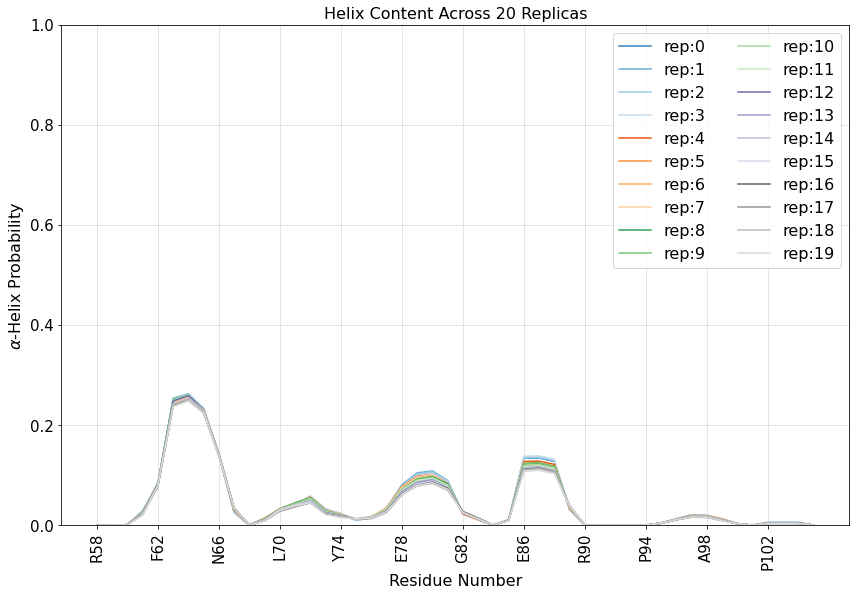

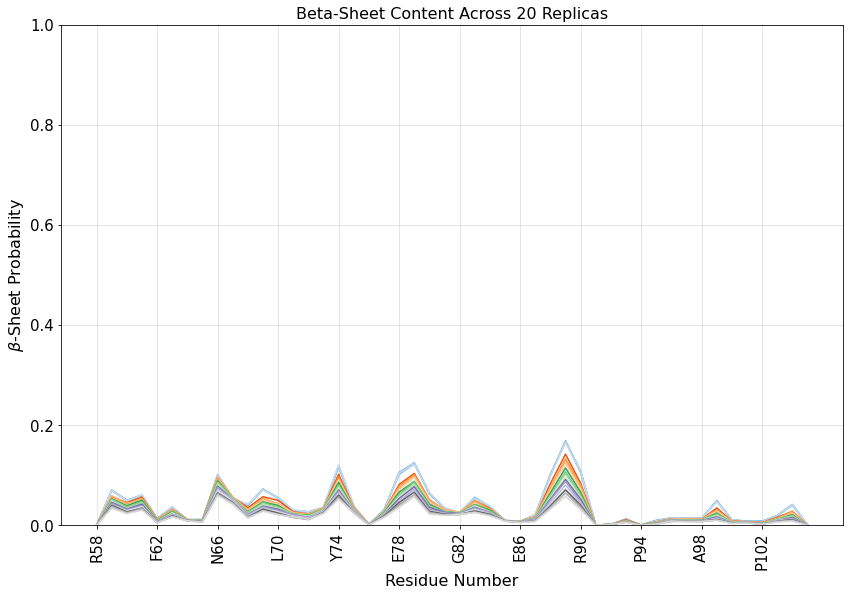

In [18]:
import numpy as np
import matplotlib.pyplot as plt

# Filter only 'rep:' keys
hc_replica = {key: hc[key] for key in hc if key.startswith('rep:')}
bsc_replica = {key: bsc[key] for key in bsc if key.startswith('rep:')}

# Sort keys numerically
keys = sorted(hc_replica.keys(), key=lambda x: int(x.split(':')[1]))

# Prepare residue indices (assuming 48 residues)
residues = np.arange(1, 49)

# ---------------------------
# 1️⃣ Helix content plot
# ---------------------------
plt.figure(figsize=(12, 8))
cmap = plt.cm.get_cmap('tab20c', len(keys))
colors = [cmap(i) for i in range(len(keys))]

for i, key in enumerate(keys):
    data = np.array(hc_replica[key])
    helix_content = data[:, 0]
    helix_error = data[:, 1]
    plt.plot(residues, helix_content, lw=1.5, color=colors[i], label=key)
    # plt.fill_between(residues, helix_content - helix_error, helix_content + helix_error,
    #                  color=colors[i], alpha=0.2)

plt.xlabel('Residue Number', fontsize=16)
plt.ylabel(r'$\alpha$-Helix Probability', fontsize=16)
plt.title('Helix Content Across 20 Replicas', fontsize=16)
#plt.legend(ncol=2, fontsize=16, title='Replica', title_fontsize=14, frameon=True)
plt.legend(ncol=2, fontsize=16,frameon=True)

plt.grid(alpha=0.4)
plt.tight_layout()
plt.ylim(0,1.0)
spaced_ticks = residues_hc[::4]
spaced_labels = single_letter_sequence[::4]
plt.xticks(ticks=spaced_ticks, labels=spaced_labels, rotation=90, fontsize=15)
plt.yticks(fontsize=15)
plt.savefig(outdir + 'helix_content_all_reps.png', dpi=800)
plt.show()

# ---------------------------
# 2️⃣ Beta-sheet content plot
# ---------------------------
plt.figure(figsize=(12, 8))
for i, key in enumerate(keys):
    data = np.array(bsc_replica[key])
    sheet_content = data[:, 0]
    sheet_error = data[:, 1]
    plt.plot(residues, sheet_content, lw=1.5, color=colors[i], label=key)
    # plt.fill_between(residues, sheet_content - sheet_error, sheet_content + sheet_error,
    #                  color=colors[i], alpha=0.2)

plt.xlabel('Residue Number', fontsize=16)
plt.ylabel(r'$\beta$-Sheet Probability', fontsize=16)
plt.title('Beta-Sheet Content Across 20 Replicas', fontsize=16)
# plt.legend(ncol=2, fontsize=10, title='Replica', title_fontsize=11, frameon=False)
plt.grid(alpha=0.4)
plt.tight_layout()
plt.ylim(0,1.0)
plt.yticks(fontsize=15)
spaced_ticks = residues_hc[::4]
spaced_labels = single_letter_sequence[::4]
plt.xticks(ticks=spaced_ticks, labels=spaced_labels, rotation=90, fontsize=15)
plt.savefig(outdir + 'sheet_content_all_reps.png', dpi=800)
plt.show()


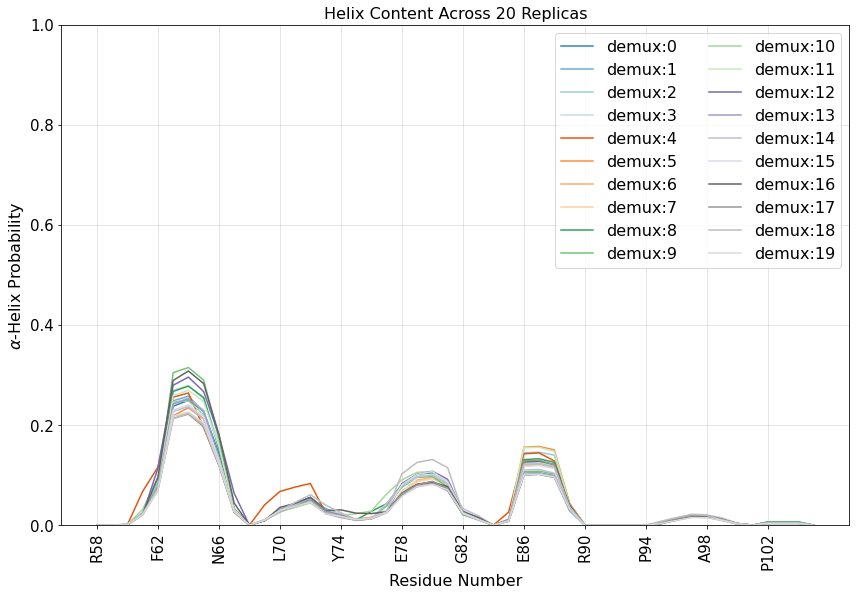

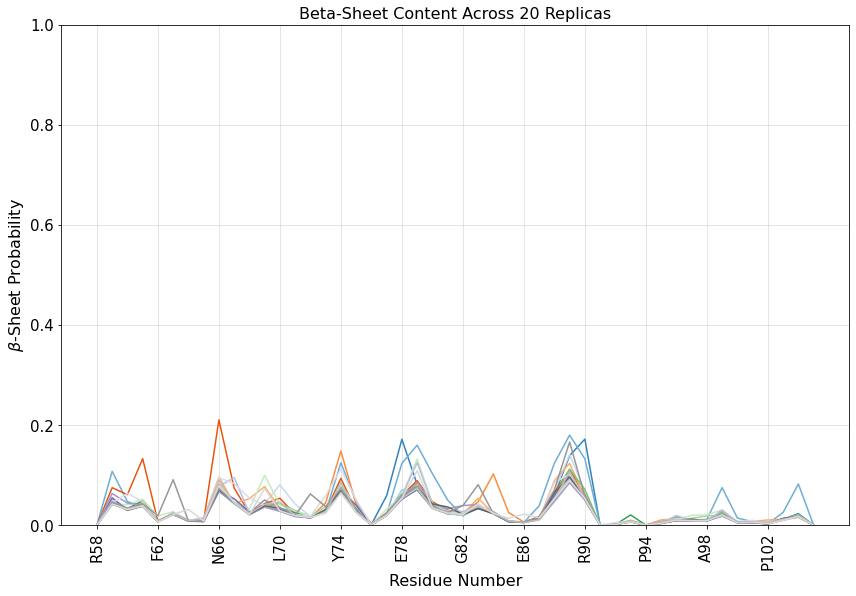

In [19]:
import numpy as np
import matplotlib.pyplot as plt

# Filter only 'rep:' keys
hc_replica = {key: hc[key] for key in hc if key.startswith('demux:')}
bsc_replica = {key: bsc[key] for key in bsc if key.startswith('demux:')}

# Sort keys numerically
keys = sorted(hc_replica.keys(), key=lambda x: int(x.split(':')[1]))

# Prepare residue indices (assuming 48 residues)
residues = np.arange(1, 49)

# ---------------------------
# 1️⃣ Helix content plot
# ---------------------------
plt.figure(figsize=(12, 8))
cmap = plt.cm.get_cmap('tab20c', len(keys))
colors = [cmap(i) for i in range(len(keys))]

for i, key in enumerate(keys):
    data = np.array(hc_replica[key])
    helix_content = data[:, 0]
    helix_error = data[:, 1]
    plt.plot(residues, helix_content, lw=1.5, color=colors[i], label=key)
    # plt.fill_between(residues, helix_content - helix_error, helix_content + helix_error,
    #                  color=colors[i], alpha=0.2)

plt.xlabel('Residue Number', fontsize=16)
plt.ylabel(r'$\alpha$-Helix Probability', fontsize=16)
plt.title('Helix Content Across 20 Replicas', fontsize=16)
#plt.legend(ncol=2, fontsize=16, title='Replica', title_fontsize=14, frameon=True)
plt.legend(ncol=2, fontsize=16,frameon=True, loc='upper right')

plt.grid(alpha=0.4)
plt.tight_layout()
plt.ylim(0,1.0)
spaced_ticks = residues_hc[::4]
spaced_labels = single_letter_sequence[::4]
plt.xticks(ticks=spaced_ticks, labels=spaced_labels, rotation=90, fontsize=15)
plt.yticks(fontsize=15)
plt.savefig(outdir + 'helix_content_all_dmx.png', dpi=800)
plt.show()

# ---------------------------
# 2️⃣ Beta-sheet content plot
# ---------------------------
plt.figure(figsize=(12, 8))
for i, key in enumerate(keys):
    data = np.array(bsc_replica[key])
    sheet_content = data[:, 0]
    sheet_error = data[:, 1]
    plt.plot(residues, sheet_content, lw=1.5, color=colors[i], label=key)
    # plt.fill_between(residues, sheet_content - sheet_error, sheet_content + sheet_error,
    #                  color=colors[i], alpha=0.2)

plt.xlabel('Residue Number', fontsize=16)
plt.ylabel(r'$\beta$-Sheet Probability', fontsize=16)
plt.title('Beta-Sheet Content Across 20 Replicas', fontsize=16)
# plt.legend(ncol=2, fontsize=10, title='Replica', title_fontsize=11, frameon=False)
plt.grid(alpha=0.4)
plt.tight_layout()
plt.ylim(0,1.0)
plt.yticks(fontsize=15)
spaced_ticks = residues_hc[::4]
spaced_labels = single_letter_sequence[::4]
plt.xticks(ticks=spaced_ticks, labels=spaced_labels, rotation=90, fontsize=15)
plt.savefig(outdir + 'sheet_content_all_dmx.png', dpi=800)
plt.show()


In [20]:
import matplotlib.pyplot as plt
import numpy as np

def pmf1d(x, nbins, range=None, weights=None, return_bin_centers=True):
    count, edge = np.histogram(x, bins=nbins, range=range, weights=weights)
    if weights is None:
        p = count / len(x)
    else:
        p = count
    if return_bin_centers:
        return p, edge[:-1] + np.diff(edge) / 2
    else:
        return p



# Function to plot subplots
def plot_rg_subplots(keys, nbins=50):
    ncol = 5
    nrow = 4 # Calculate number of rows needed
    fig, axes = plt.subplots(nrow, ncol, figsize=(20, 20))

    for i, key in enumerate(keys):
        x = rg[key]  # Assuming rg[key] gives the data for each key
        p, bc = pmf1d(x, nbins=nbins)

        row_idx = i // ncol
        col_idx = i % ncol
        ax = axes[row_idx, col_idx]

        ax.plot(bc, p)
        ax.fill_between(bc, p, alpha=0.3, label='Rg Probability')
        ax.set_title(key, fontsize=16)
        ax.set_xlabel('Radius of Gyration [nm]', fontsize=14)
        ax.set_ylabel('Probability', fontsize=14)
        ax.legend(loc='upper right', fontsize=12)

    plt.tight_layout()
    plt.savefig('%s/Rg_probabilities_subplots.pdf' % outdir, bbox_inches='tight')
    plt.show()



In [21]:
# rg_keys_rep = [key for key in rg.keys() if key.startswith('rep:')]
# plot_rg_subplots(rg_keys_rep)

In [22]:
# rg_keys_dmx = [key for key in rg.keys() if key.startswith('demux:')]
# plot_rg_subplots(rg_keys_dmx)

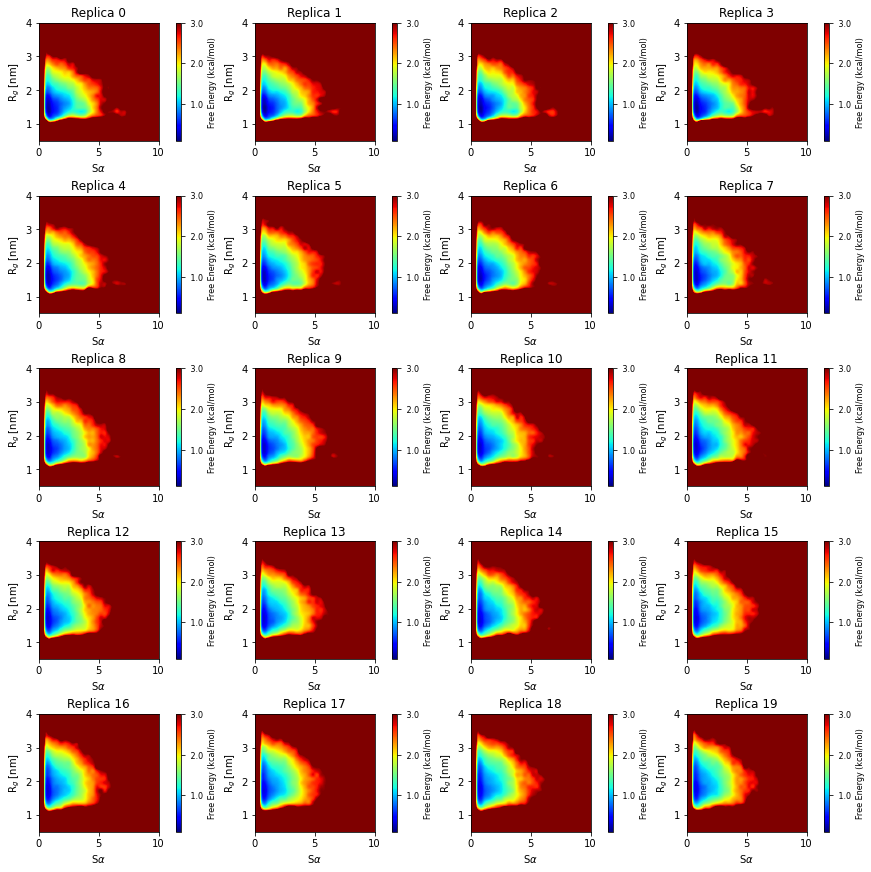

In [23]:
import numpy as np
import matplotlib.pyplot as plt

def plot_Rg_vs_Sa_subplot(ax, a, b, T, y0, ymax, x0, xmax, weight=None, title=""):
    # Calculate free energy
    free_energy, xedges, yedges = np.histogram2d(
        a, b, bins=30, range=[[y0, ymax], [x0, xmax]], density=True, weights=weight)
    free_energy = np.log(np.flipud(free_energy) + 0.000001)
    free_energy = -(0.001987 * T) * free_energy

    # Define the color scale limits
    vmin, vmax = 0.1, 3.0  # Ensures the colorbar is capped at 3 kcal/mol
    cbar_ticks = [0, 1, 2, 3]

    # Plot heatmap with color limits
    im = ax.imshow(free_energy, interpolation='gaussian', extent=[yedges[0], yedges[-1], xedges[0], xedges[-1]],
                   cmap='jet', aspect='auto', vmin=vmin, vmax=vmax)
    
    ax.set_title(title, fontsize=12)
    ax.set_xlabel(r"S$\alpha$", fontsize=10)
    ax.set_ylabel(r"R$_g$ [nm]", fontsize=10)

    # Add colorbar with proper limits
    cbar = plt.colorbar(im, ax=ax, ticks=cbar_ticks, format='% .1f')
    cbar.set_label("Free Energy (kcal/mol)", fontsize=8)
    cbar.ax.tick_params(labelsize=8)

# Define parameters
T = 300
y0, ymax = 0.5, 4.0
x0, xmax = 0.0, 10.0

# Create subplots
fig, axes = plt.subplots(5, 4, figsize=(12, 12), constrained_layout=True)
axes = axes.flatten()

# Loop through replicas
for i in range(20):
    rep_key = f'rep:{i}'
    sa_i = np.asarray(sa[rep_key])
    sa_total = np.sum(sa_i, axis=0)  # Summing over the 43 lists for each frame
    plot_Rg_vs_Sa_subplot(axes[i], rg[rep_key], sa_total, T, y0, ymax, x0, xmax, title=f"Replica {i}")

plt.show()

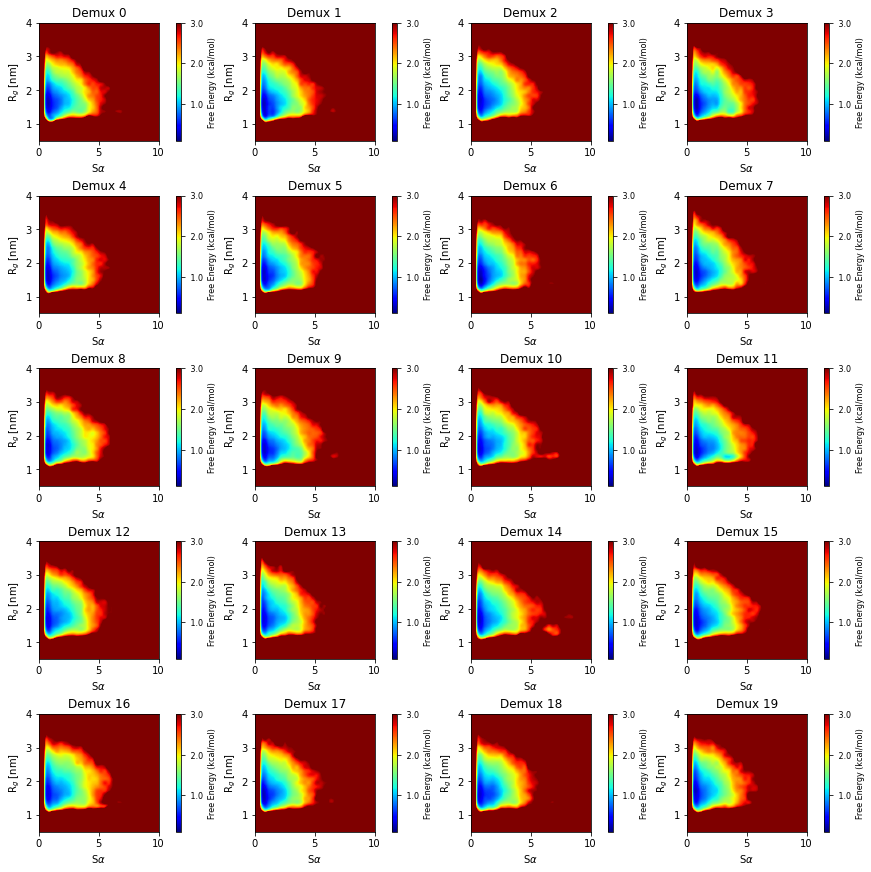

In [24]:
# Define parameters
T = 300
y0, ymax = 0.5, 4.0
x0, xmax = 0.0, 10.0

# Create subplots
fig, axes = plt.subplots(5, 4, figsize=(12, 12), constrained_layout=True)
axes = axes.flatten()

# Loop through replicas
for i in range(20):
    rep_key = f'demux:{i}'
    sa_i = np.asarray(sa[rep_key])
    sa_total = np.sum(sa_i, axis=0)  # Summing over the 43 lists for each frame
    plot_Rg_vs_Sa_subplot(axes[i], rg[rep_key], sa_total, T, y0, ymax, x0, xmax, title=f"Demux {i}")

plt.show()

In [25]:

def pmf1d(x, nbins, range=None, weights=None, return_bin_centers=True):
    count, edge = np.histogram(x, bins=nbins, range=range, weights=weights)
    if weights is None:
        p = count / len(x)
    else:
        p = count
    if return_bin_centers:
        return p, edge[:-1] + np.diff(edge) / 2
    else:
        return p

def plot_rg_dist(rg_dict, nbins=50, outdir='.', cmap_name='tab20c', mode='rep', filename=str):


    # Filter keys based on mode
    if mode == 'rep':
        keys = [k for k in rg_dict.keys() if k.startswith('rep:')]
        title = 'Rg Distributions Across Temperature Replicas'
        filename = 'Rg_probabilities_reps.pdf'
    elif mode == 'demux':
        keys = [k for k in rg_dict.keys() if k.startswith('demux:')]
        title = 'Rg Distributions Across Demuxed Replicas'
        filename = 'Rg_probabilities_demux.pdf'
    else:
        raise ValueError("mode must be either 'rep' or 'demux'")

    keys.sort(key=lambda x: int(x.split(':')[1]))

    plt.figure(figsize=(8, 6))
    cmap = plt.cm.get_cmap(cmap_name, len(keys))
    colors = [cmap(i) for i in range(len(keys))]

    for i, key in enumerate(keys):
        x = rg_dict[key]
        p, bc = pmf1d(x, nbins=nbins)
        plt.plot(bc, p, color=colors[i], lw=2, label=key)

    plt.xlabel('Radius of Gyration [nm]', fontsize=14)
    plt.ylabel('Probability Density', fontsize=14)
    plt.title(title, fontsize=16)
    plt.legend(title='Replica', fontsize=10, title_fontsize=11, ncol=2, frameon=False)
    plt.tight_layout()
    plt.savefig(f"{outdir}/{filename}", bbox_inches='tight')
    plt.show()


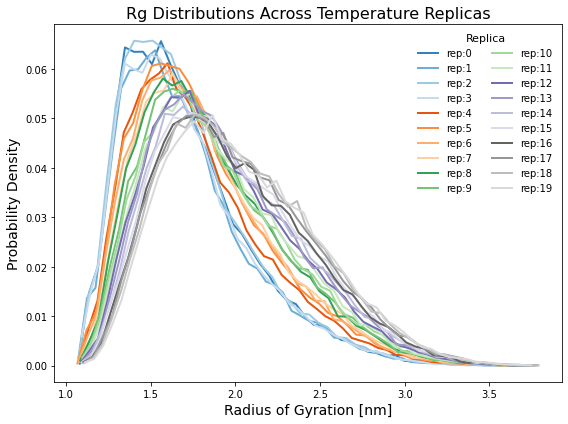

In [26]:
plot_rg_dist(rg, mode='rep', filename='rg_dist_reps.png')

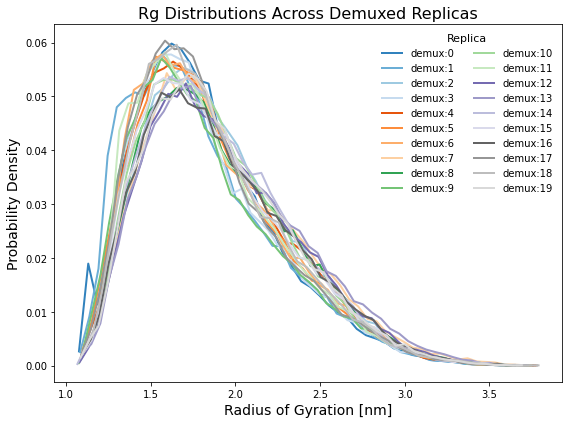

In [27]:
plot_rg_dist(rg, mode='demux', filename='rg_dist_dmx.png')

In [28]:
replicas = np.linspace(0,19,20)

In [39]:
rg_300k = np.asarray(rg['rep:0'])
import numpy as np
import pyblock

rg = np.asarray(rg_300k)

block_data = pyblock.blocking.reblock(rg)
opt = pyblock.blocking.find_optimal_block(len(rg), block_data)
opt_idx = max(opt)

chosen = block_data[opt_idx]

mean = chosen.mean
error = chosen.std_err

print(f"Naive mean: {rg.mean():.4f}")
print(f"Block mean: {mean:.4f}")
print(f"Block error: {error:.4f}")

Naive mean: 1.7075
Block mean: 1.7076
Block error: 0.0056


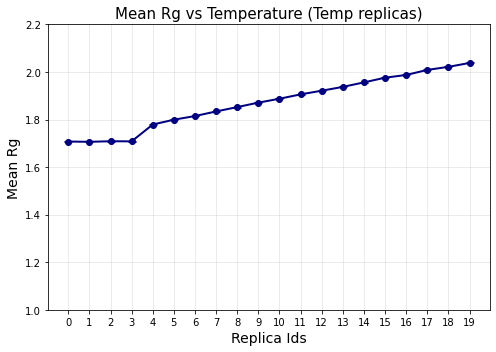

In [29]:
rg_list = [rg[key] for key in rg if 'rep' in key]
means = [np.mean(x) for x in rg_list]
sems = [np.std(x, ddof=1) / np.sqrt(len(x)) for x in rg_list]

# Plot
plt.figure(figsize=(7,5))
plt.errorbar(replicas, means, yerr=sems, fmt='o-', capsize=4, lw=2, color='navy')
plt.xlabel('Replica Ids', fontsize=14)
plt.ylabel('Mean Rg', fontsize=14)
plt.title('Mean Rg vs Temperature (Temp replicas)', fontsize=15)
plt.xticks(replicas)
plt.ylim(1.0, 2.2)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('rg_400k_mean.png', dpi=800)
plt.show()

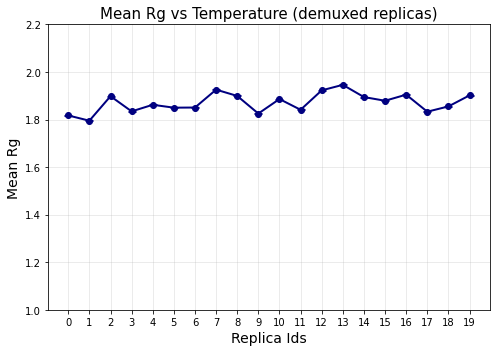

In [30]:
rg_list = [rg[key] for key in rg if 'demux' in key]

means = [np.mean(x) for x in rg_list]
sems = [np.std(x, ddof=1) / np.sqrt(len(x)) for x in rg_list]

# Plot
plt.figure(figsize=(7,5))
plt.errorbar(replicas, means, yerr=sems, fmt='o-', capsize=4, lw=2, color='navy')
plt.xlabel('Replica Ids', fontsize=14)
plt.ylabel('Mean Rg', fontsize=14)
plt.title('Mean Rg vs Temperature (demuxed replicas)', fontsize=15)
plt.xticks(replicas)
plt.ylim(1.0, 2.2)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('rg_400k_mean.png', dpi=800)
plt.show()

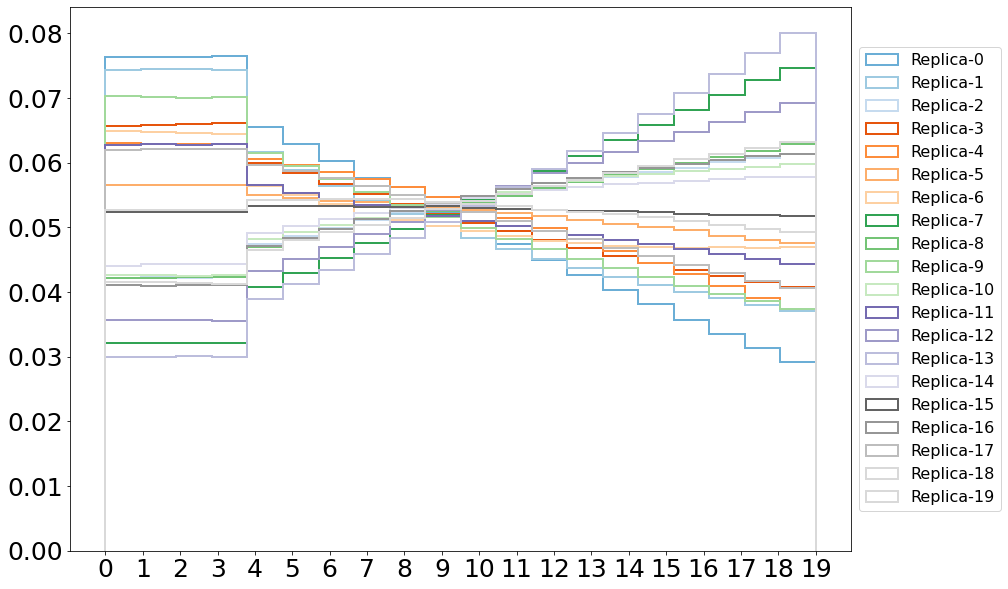

In [ ]:
data={}
data['temp'] = np.loadtxt(dir + '/d/replica_temp.xvg', comments=['@','#'])
data['index'] = np.loadtxt(dir + '/d/replica_index.xvg', comments=['@','#'] )


# nrep=20

# plt.figure(figsize=(14,10))
# for i in range(1,nrep+1):
#     plt.hist(data['temp'].T[i],histtype='step',density='true',linewidth=2,
#              color=plt.cm.tab20c(i),label='Replica-'+str(i-1),bins=nrep)
    
# plt.tick_params(labelsize=25)
# plt.xticks(range(nrep))
# plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=16)

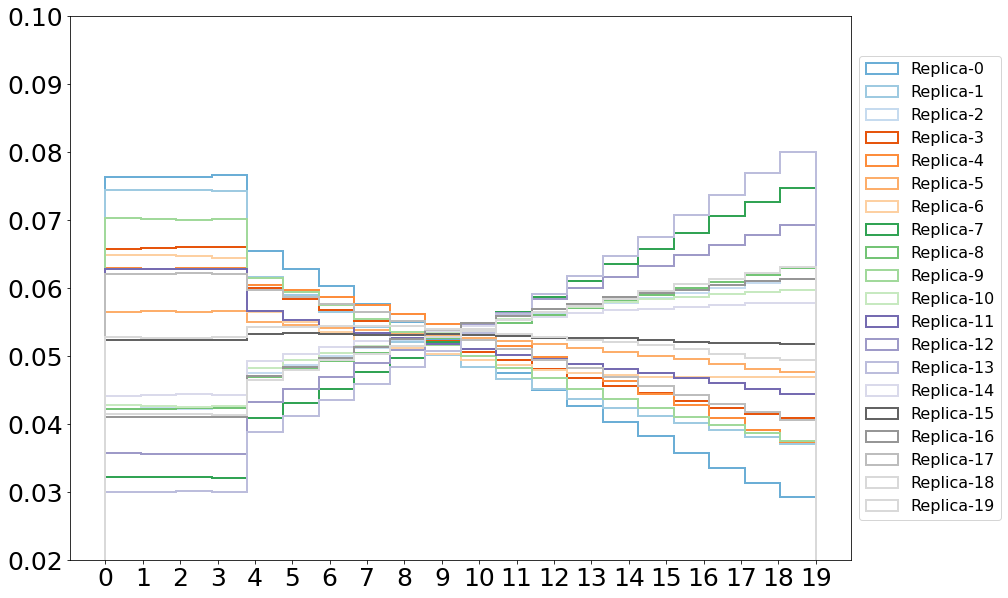

In [32]:
nrep=20

plt.figure(figsize=(14,10))
for i in range(1,nrep+1):
    plt.hist(data['temp'].T[i],histtype='step',density='true',linewidth=2,
             color=plt.cm.tab20c(i),label='Replica-'+str(i-1),bins=nrep)
    
plt.tick_params(labelsize=25)
plt.xticks(range(nrep))
plt.ylim(0.02,0.1)
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=16)

In [33]:
nres = len(residues)

In [34]:
import numpy as np

def plot_cmaps(map_data, sequence, title="", filename=""):
    map_data = np.asarray(map_data)      # ✅ convert list -> ndarray
    nres = map_data.shape[0]

    fig = plt.figure(figsize=(10,8))
    ax = fig.add_subplot(111)

    im = sns.heatmap(map_data, cmap='jet', ax=ax)
    ax.grid(which='both', alpha=0.5)

    labels = sequence[:nres]
    ax.set_xticks(range(nres))
    ax.set_yticks(range(nres))
    ax.set_xticklabels(labels, rotation=45, fontsize=22)
    ax.set_yticklabels(labels, rotation=45, fontsize=22)

    cbar = im.collections[0].colorbar
    cbar.ax.tick_params(labelsize=30)
    cbar.set_label('Residue contact probability', labelpad=35, fontsize=30, rotation=270)

    ax.set_title(title, size=30, pad=20, fontweight='bold')
    ax.invert_yaxis()
    plt.tight_layout()

    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(3)
    for spine in cbar.ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(3)

    filepath = os.path.join(outdir, filename)
    plt.savefig(filepath)


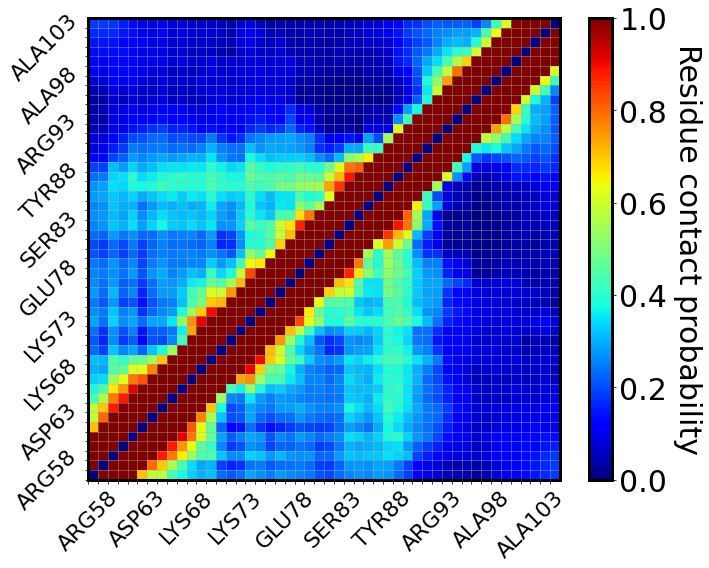

In [35]:
plot_cmaps(contact_map_p['rep:0'], sequence, title='', filename="prot_only_cmap.pdf")


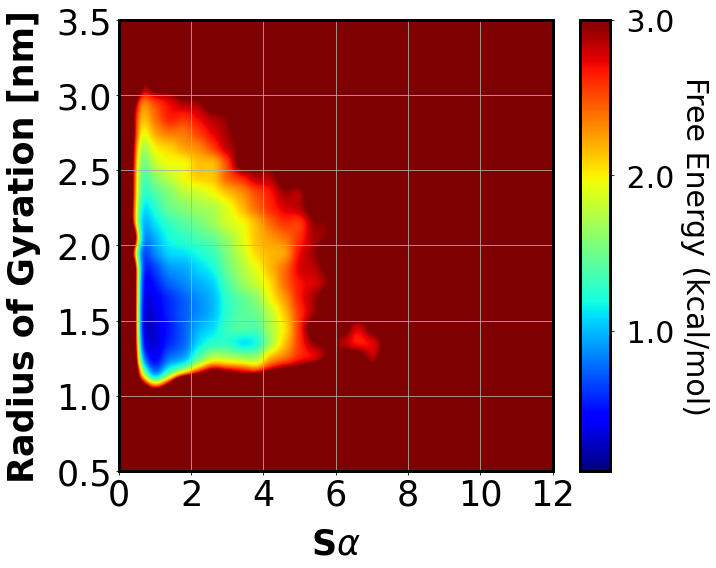

In [36]:
sa_total_rep0 = np.sum(sa['rep:0'], axis=0)


plt.rcParams["axes.edgecolor"] = "black"
plt.rcParams["axes.linewidth"] = 3.0

def plot_Rg_vs_Sa(a, b, T, y0, ymax, x0, xmax, scatter_x=None, scatter_y=None, weight=None, title="", filename="plot.pdf"):
    # Calculate free energy
    free_energy, xedges, yedges = np.histogram2d(
        a, b, 30, [[y0, ymax], [x0, xmax]], normed=True, weights=weight)
    free_energy = np.log(np.flipud(free_energy) + 0.000001)
    free_energy = -(0.001987 * T) * free_energy

    # Create and customize the plot
    fig = plt.figure(figsize=(10, 8))
    plt.scatter(scatter_x, scatter_y, marker='.', c='white', s=800, edgecolors='black', alpha=0.8)
    im = plt.imshow(free_energy, interpolation='gaussian', extent=[yedges[0], yedges[-1], xedges[0], xedges[-1]],
                    cmap='jet', aspect='auto')
    plt.title(title, fontsize=25, fontweight='bold', pad=20)
    cbar_ticks = [0, 1, 2, 3]
    cb = plt.colorbar(ticks=cbar_ticks, format=('% .1f'), aspect=15)
    cb.set_label("Free Energy (kcal/mol)", labelpad=35, fontsize=30, rotation=270)
    imaxes = plt.gca()
    plt.ylabel("Radius of Gyration [nm]", size=35, labelpad=15, fontweight='bold')
    plt.xlabel(r"S$\alpha$", size=35, labelpad=15, fontweight='bold')
    plt.xticks(fontsize=35)
    plt.yticks(fontsize=35)
    plt.grid()
    plt.xlim(0,12)
    plt.axes(cb.ax)
    plt.clim(vmin=0.1, vmax=3.0)
    cb.ax.tick_params(labelsize=30)
    

    file_path = os.path.join(outdir, filename)
    
    
    plt.tight_layout()
    plt.savefig(file_path)
    plt.show()
    
    

plot_Rg_vs_Sa(rg['rep:0'], sa_total_rep0, 300, 0.5, 3.5, 0, 12, scatter_x=None, scatter_y=None, weight=None, title='', filename='unbiased.rg_vs_sa.pdf')

In [62]:
!ls

Rg_probabilities_demux.pdf     out_d
Rg_probabilities_reps.pdf      p27_res58_105_1H_15N_CSP.csv
W76A_SJ4_LC.json               plots
W76A_res58_105_1H_15N_CSP.csv  prot.pdb
W76A_res58_105_Average_CSP.csv r
WT_SJ4_LC.json                 rep.0.xtc
apo_W76A_20reps.ipynb          rg_400k_mean.png
d


In [63]:
# hc_w76apo = json.load(open(dir+'/W76_apo_hc.json','r'))
# hc_w76apo = np.array(hc_w76apo['rep:0'])
# hc_w76_sj4 = json.load(open(dir+'/W76_SJ4_hc.json','r'))
# hc_w76_sj4 = np.array(hc_w76_sj4['rep:0'])
# hc_wt_apo = json.load(open(dir+'/WT_apo_hc.json','r'))
# hc_wt_apo = np.array(hc_wt_apo['rep:0'])
# hc_wt_sj4 = json.load(open(dir+'/WT_SJ4_hc.json','r'))
# hc_wt_sj4 = np.array(hc_wt_sj4['rep:0'])

In [64]:

# import numpy as np
# import matplotlib.pyplot as plt

# # adjustable parameters
# n_xticks = 16
# tick_fontsize = 16
# label_fontsize = 18
# legend_fontsize = 20
# title_fontsize = 20

# # x positions
# x = np.arange(1, len(single_letter_sequence) + 1)

# # means and errors
# wt_apo_mean,  wt_apo_err  = hc_wt_apo[:,0],  hc_wt_apo[:,1]
# wt_sj4_mean,  wt_sj4_err  = hc_wt_sj4[:,0],  hc_wt_sj4[:,1]
# w76_apo_mean, w76_apo_err = hc_w76apo[:,0], hc_w76apo[:,1]
# w76_sj4_mean, w76_sj4_err = hc_w76_sj4[:,0], hc_w76_sj4[:,1]

# fig, ax = plt.subplots(figsize=(16,6))

# # WT apo
# ax.plot(x, wt_apo_mean, lw=1.5, label='WT apo')
# ax.fill_between(x, wt_apo_mean-wt_apo_err, wt_apo_mean+wt_apo_err, alpha=0.25)

# # WT + SJ403
# ax.plot(x, wt_sj4_mean, lw=1.5, label='WT + SJ403')
# ax.fill_between(x, wt_sj4_mean-wt_sj4_err, wt_sj4_mean+wt_sj4_err, alpha=0.25)

# # W76A apo
# ax.plot(x, w76_apo_mean, lw=1.5, label='W76A apo')
# ax.fill_between(x, w76_apo_mean-w76_apo_err, w76_apo_mean+w76_apo_err, alpha=0.25)

# # W76A + SJ403
# ax.plot(x, w76_sj4_mean, lw=1.5, label='W76A + SJ403')
# ax.fill_between(x, w76_sj4_mean-w76_sj4_err, w76_sj4_mean+w76_sj4_err, alpha=0.25)

# ax.set_xlim(1, len(single_letter_sequence))
# ax.set_ylim(0,1)

# ax.set_xlabel("Sequence", fontsize=label_fontsize)
# ax.set_ylabel(r"$\alpha$ Helix content", fontsize=label_fontsize)
# # ax.set_title("Per-residue helix content", fontsize=title_fontsize)

# # select evenly spaced ticks
# step = len(x) // n_xticks
# tick_positions = x[::step]
# tick_labels = np.array(single_letter_sequence)[::step]

# ax.set_xticks(tick_positions)
# ax.set_xticklabels(tick_labels, fontsize=tick_fontsize)

# ax.tick_params(axis='y', labelsize=tick_fontsize)

# ax.legend(frameon=False, fontsize=legend_fontsize)

# plt.ylim(0, 0.5)

# plt.tight_layout()
# plt.show()

In [65]:
# import numpy as np
# import matplotlib.pyplot as plt

# # adjustable parameters
# n_xticks = 16
# tick_fontsize = 16
# label_fontsize = 18
# legend_fontsize = 20

# # x positions
# x = np.arange(1, len(single_letter_sequence) + 1)

# # means and errors
# wt_apo_mean,  wt_apo_err  = hc_wt_apo[:,0],   hc_wt_apo[:,1]
# wt_sj4_mean,  wt_sj4_err  = hc_wt_sj4[:,0],   hc_wt_sj4[:,1]
# w76_apo_mean, w76_apo_err = hc_w76apo[:,0],   hc_w76apo[:,1]
# w76_sj4_mean, w76_sj4_err = hc_w76_sj4[:,0],  hc_w76_sj4[:,1]

# # differences
# diff_w76apo_vs_wtapo = w76_apo_mean - wt_apo_mean
# diff_wtsj4_vs_wtapo  = wt_sj4_mean - wt_apo_mean
# diff_w76sj4_vs_wtapo = w76_sj4_mean - wt_apo_mean

# # propagated errors: sigma_diff = sqrt(sigma1^2 + sigma2^2)
# err_w76apo_vs_wtapo = np.sqrt(w76_apo_err**2 + wt_apo_err**2)
# err_wtsj4_vs_wtapo  = np.sqrt(wt_sj4_err**2 + wt_apo_err**2)
# err_w76sj4_vs_wtapo = np.sqrt(w76_sj4_err**2 + wt_apo_err**2)

# fig, ax = plt.subplots(figsize=(16,6))

# # W76A apo - WT apo
# ax.plot(x, diff_w76apo_vs_wtapo, lw=1.5, label='W76A apo - WT apo')
# ax.fill_between(
#     x,
#     diff_w76apo_vs_wtapo - err_w76apo_vs_wtapo,
#     diff_w76apo_vs_wtapo + err_w76apo_vs_wtapo,
#     alpha=0.25
# )

# # WT + SJ4 - WT apo
# ax.plot(x, diff_wtsj4_vs_wtapo, lw=1.5, label='WT + SJ403 - WT apo')
# ax.fill_between(
#     x,
#     diff_wtsj4_vs_wtapo - err_wtsj4_vs_wtapo,
#     diff_wtsj4_vs_wtapo + err_wtsj4_vs_wtapo,
#     alpha=0.25
# )

# # W76A + SJ4 - WT apo
# ax.plot(x, diff_w76sj4_vs_wtapo, lw=1.5, label='W76A + SJ403 - WT apo')
# ax.fill_between(
#     x,
#     diff_w76sj4_vs_wtapo - err_w76sj4_vs_wtapo,
#     diff_w76sj4_vs_wtapo + err_w76sj4_vs_wtapo,
#     alpha=0.25
# )

# # zero line
# ax.axhline(0, color='black', lw=1, ls='--')

# ax.set_xlim(1, len(single_letter_sequence))
# ax.set_xlabel("Sequence", fontsize=label_fontsize)
# ax.set_ylabel(r"$\Delta$ $\alpha$-helix content", fontsize=label_fontsize)

# # evenly spaced ticks
# step = max(1, len(x) // n_xticks)
# tick_positions = x[::step]
# tick_labels = np.array(single_letter_sequence)[::step]

# ax.set_xticks(tick_positions)
# ax.set_xticklabels(tick_labels, fontsize=tick_fontsize)
# ax.tick_params(axis='y', labelsize=tick_fontsize)

# ax.legend(frameon=False, fontsize=legend_fontsize)

# plt.tight_layout()
# plt.show()

In [66]:
# sc_w76apo = json.load(open(dir+'/W76_apo_sc.json','r'))
# sc_w76apo = np.array(sc_w76apo['rep:0'])
# sc_w76_sj4 = json.load(open(dir+'/W76_SJ4_sc.json','r'))
# sc_w76_sj4 = np.array(sc_w76_sj4['rep:0'])
# sc_wt_apo = json.load(open(dir+'/WT_apo_sc.json','r'))
# sc_wt_apo = np.array(sc_wt_apo['rep:0'])
# sc_wt_sj4 = json.load(open(dir+'/WT_SJ4_sc.json','r'))
# sc_wt_sj4 = np.array(sc_wt_sj4['rep:0'])

In [67]:
# import numpy as np
# import matplotlib.pyplot as plt

# # adjustable parameters
# n_xticks = 16
# tick_fontsize = 16
# label_fontsize = 18
# legend_fontsize = 20
# title_fontsize = 20

# # x positions
# x = np.arange(1, len(single_letter_sequence) + 1)

# # means and errors
# wt_apo_mean,  wt_apo_err  = sc_wt_apo[:,0],  sc_wt_apo[:,1]
# wt_sj4_mean,  wt_sj4_err  = sc_wt_sj4[:,0],  sc_wt_sj4[:,1]
# w76_apo_mean, w76_apo_err = sc_w76apo[:,0], sc_w76apo[:,1]
# w76_sj4_mean, w76_sj4_err = sc_w76_sj4[:,0], sc_w76_sj4[:,1]

# fig, ax = plt.subplots(figsize=(16,6))

# # WT apo
# ax.plot(x, wt_apo_mean, lw=1.5, label='WT apo')
# ax.fill_between(x, wt_apo_mean-wt_apo_err, wt_apo_mean+wt_apo_err, alpha=0.25)

# # WT + SJ403
# ax.plot(x, wt_sj4_mean, lw=1.5, label='WT + SJ403')
# ax.fill_between(x, wt_sj4_mean-wt_sj4_err, wt_sj4_mean+wt_sj4_err, alpha=0.25)

# # W76A apo
# ax.plot(x, w76_apo_mean, lw=1.5, label='W76A apo')
# ax.fill_between(x, w76_apo_mean-w76_apo_err, w76_apo_mean+w76_apo_err, alpha=0.25)

# # W76A + SJ403
# ax.plot(x, w76_sj4_mean, lw=1.5, label='W76A + SJ403')
# ax.fill_between(x, w76_sj4_mean-w76_sj4_err, w76_sj4_mean+w76_sj4_err, alpha=0.25)

# ax.set_xlim(1, len(single_letter_sequence))
# ax.set_ylim(0,1)

# ax.set_xlabel("Sequence", fontsize=label_fontsize)
# ax.set_ylabel(r"$\beta$ Sheet content", fontsize=label_fontsize)
# # ax.set_title("Per-residue helix content", fontsize=title_fontsize)

# # select evenly spaced ticks
# step = len(x) // n_xticks
# tick_positions = x[::step]
# tick_labels = np.array(single_letter_sequence)[::step]

# ax.set_xticks(tick_positions)
# ax.set_xticklabels(tick_labels, fontsize=tick_fontsize)

# ax.tick_params(axis='y', labelsize=tick_fontsize)

# ax.legend(frameon=False, fontsize=legend_fontsize)

# plt.ylim(0, 0.4)

# plt.tight_layout()
# plt.show()

In [68]:
# import numpy as np
# import matplotlib.pyplot as plt

# # adjustable parameters
# n_xticks = 16
# tick_fontsize = 16
# label_fontsize = 18
# legend_fontsize = 20

# # x positions
# x = np.arange(1, len(single_letter_sequence) + 1)

# # means and errors
# wt_apo_mean,  wt_apo_err  = sc_wt_apo[:,0],   sc_wt_apo[:,1]
# wt_sj4_mean,  wt_sj4_err  = sc_wt_sj4[:,0],   sc_wt_sj4[:,1]
# w76_apo_mean, w76_apo_err = sc_w76apo[:,0],   sc_w76apo[:,1]
# w76_sj4_mean, w76_sj4_err = sc_w76_sj4[:,0],  sc_w76_sj4[:,1]

# # differences
# diff_w76apo_vs_wtapo = w76_apo_mean - wt_apo_mean
# diff_wtsj4_vs_wtapo  = wt_sj4_mean - wt_apo_mean
# diff_w76sj4_vs_wtapo = w76_sj4_mean - wt_apo_mean

# # propagated errors: sigma_diff = sqrt(sigma1^2 + sigma2^2)
# err_w76apo_vs_wtapo = np.sqrt(w76_apo_err**2 + wt_apo_err**2)
# err_wtsj4_vs_wtapo  = np.sqrt(wt_sj4_err**2 + wt_apo_err**2)
# err_w76sj4_vs_wtapo = np.sqrt(w76_sj4_err**2 + wt_apo_err**2)

# fig, ax = plt.subplots(figsize=(16,6))

# # W76A apo - WT apo
# ax.plot(x, diff_w76apo_vs_wtapo, lw=1.5, label='W76A apo - WT apo')
# ax.fill_between(
#     x,
#     diff_w76apo_vs_wtapo - err_w76apo_vs_wtapo,
#     diff_w76apo_vs_wtapo + err_w76apo_vs_wtapo,
#     alpha=0.25
# )

# # WT + SJ4 - WT apo
# ax.plot(x, diff_wtsj4_vs_wtapo, lw=1.5, label='WT + SJ403 - WT apo')
# ax.fill_between(
#     x,
#     diff_wtsj4_vs_wtapo - err_wtsj4_vs_wtapo,
#     diff_wtsj4_vs_wtapo + err_wtsj4_vs_wtapo,
#     alpha=0.25
# )

# # W76A + SJ4 - WT apo
# ax.plot(x, diff_w76sj4_vs_wtapo, lw=1.5, label='W76A + SJ403 - WT apo')
# ax.fill_between(
#     x,
#     diff_w76sj4_vs_wtapo - err_w76sj4_vs_wtapo,
#     diff_w76sj4_vs_wtapo + err_w76sj4_vs_wtapo,
#     alpha=0.25
# )

# # zero line
# ax.axhline(0, color='black', lw=1, ls='--')

# ax.set_xlim(1, len(single_letter_sequence))
# ax.set_xlabel("Sequence", fontsize=label_fontsize)
# ax.set_ylabel(r"$\Delta$ $\beta$-sheet content", fontsize=label_fontsize)

# # evenly spaced ticks
# step = max(1, len(x) // n_xticks)
# tick_positions = x[::step]
# tick_labels = np.array(single_letter_sequence)[::step]

# ax.set_xticks(tick_positions)
# ax.set_xticklabels(tick_labels, fontsize=tick_fontsize)
# ax.tick_params(axis='y', labelsize=tick_fontsize)

# ax.legend(frameon=False, fontsize=legend_fontsize)

# plt.tight_layout()
# plt.show()

In [69]:
# wt_apo_rg = np.array(json.load(open('WT_apo_rg.json','r'))['rep:0'])
# wt_sj_rg = np.array(json.load(open('WT_SJ_rg.json','r'))['rep:0'])
# w76_apo_rg = np.array(json.load(open('W76_apo_rg.json','r'))['rep:0'])
# w76_sj_rg = np.array(json.load(open('W76_SJ4_rg.json','r'))['rep:0'])


In [70]:
# print(wt_apo_rg.shape)
# print(wt_sj_rg.shape)
# print(w76_apo_rg.shape)
# print(w76_sj_rg.shape)

In [71]:
# import numpy as np
# import matplotlib.pyplot as plt

# nbins = 60

# # compute pmfs independently
# p_wt_apo, x_wt_apo = pmf1d(wt_apo_rg, nbins)
# p_wt_sj,  x_wt_sj  = pmf1d(wt_sj_rg, nbins)
# p_w76_apo, x_w76_apo = pmf1d(w76_apo_rg, nbins)
# p_w76_sj,  x_w76_sj  = pmf1d(w76_sj_rg, nbins)

# fig, ax = plt.subplots(figsize=(8,6))

# ax.plot(x_wt_apo, p_wt_apo, lw=2.5, color='C0', label='WT apo')
# ax.plot(x_wt_sj,  p_wt_sj,  lw=2.5, color='C1', label='WT + SJ403')
# ax.plot(x_w76_apo, p_w76_apo, lw=2.5, color='C2', label='W76A apo')
# ax.plot(x_w76_sj,  p_w76_sj,  lw=2.5, color='C3', label='W76A + SJ403')

# ax.set_xlabel("Radius of gyration (nm)", fontsize=16)
# ax.set_ylabel("Probability", fontsize=16)

# ax.tick_params(axis='both', labelsize=14)
# ax.legend(frameon=False, fontsize=13)

# plt.tight_layout()
# plt.show()

In [72]:
dir

'/Users/kaushikborthakur1211/Desktop/p27/New_2025_runs/kappa_tests/mutants/W76A/apo/xtc_files'

In [73]:
# wt_con = np.array(json.load(open('WT_SJ4_LC.json','r'))['rep:0'])
# w76_con = np.array(json.load(open('W76A_SJ4_LC.json','r'))['rep:0'])

In [74]:
# import numpy as np
# import matplotlib.pyplot as plt

# # arrays
# # wt_con, w76_con -> shape (48,3)
# # columns: residue_number, probability, error

# # extract values
# wt_prob  = wt_con[:,1]
# wt_err   = wt_con[:,2]

# w76_prob = w76_con[:,1]
# w76_err  = w76_con[:,2]

# nres = len(single_letter_sequence)
# x = np.arange(nres)

# # bar width
# width = 0.4

# # plotting
# fig, ax = plt.subplots(figsize=(18,6))

# ax.bar(x - width/2, wt_prob, width,
#        yerr=wt_err,
#        color='C1',
#        label='WT + SJ403',
#        capsize=3)

# ax.bar(x + width/2, w76_prob, width,
#        yerr=w76_err,
#        color='C3',
#        label='W76A + SJ403',
#        capsize=3)

# # axis labels
# ax.set_ylabel("Ligand contact probability", fontsize=18)
# ax.set_xlabel("Residue", fontsize=18)

# # xtick spacing (like helix plot)
# n_xticks = 16
# step = nres // n_xticks
# tick_positions = x[::step]
# tick_labels = np.array(single_letter_sequence)[::step]

# ax.set_xticks(tick_positions)
# ax.set_xticklabels(tick_labels, fontsize=14)

# ax.tick_params(axis='y', labelsize=14)

# ax.legend(frameon=False, fontsize=14)

# plt.tight_layout()
# plt.show()

In [75]:
# import pandas as pd
# wt_csp = pd.read_csv('p27_res58_105_1H_15N_CSP.csv')
# w76_csp = pd.read_csv('W76A_res58_105_1H_15N_CSP.csv')

In [76]:
# wt_csp

In [77]:
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt

# # --------------------------------------------------
# # ASSUMED INPUTS
# # --------------------------------------------------
# # wt_csp : pandas DataFrame with columns
# #          ["Residue", "Residue_Number", "1H_CSP", "15N_CSP"]
# #
# # wt_con : numpy array of shape (48, 3)
# #          col 0 = residue number
# #          col 1 = contact probability
# #          col 2 = contact error

# # spectrometer frequencies for 800 MHz instrument
# H_freq = 800.0
# N_freq = 81.056


# # --------------------------------------------------
# # CONVERT Hz -> ppm AND COMPUTE COMBINED CSP
# # --------------------------------------------------
# plot_df = wt_csp.copy()

# plot_df["Residue_Number"] = plot_df["Residue_Number"].astype(int)

# # convert component CSPs from Hz to ppm
# plot_df["1H_ppm"] = plot_df["1H_CSP"] / H_freq
# plot_df["15N_ppm"] = plot_df["15N_CSP"] / N_freq

# # combined CSP in ppm
# plot_df["Average_CSP"] = np.sqrt(
#     plot_df["1H_ppm"]**2 + (0.2 * plot_df["15N_ppm"])**2
# )

# # label for x-axis
# plot_df["Label"] = plot_df["Residue"]

# # --------------------------------------------------
# # BUILD CONTACT DATAFRAME FROM wt_con
# # --------------------------------------------------
# con_df = pd.DataFrame(
#     wt_con,
#     columns=["Residue_Number", "Contact_Prob", "Contact_Error"]
# )
# con_df["Residue_Number"] = con_df["Residue_Number"].astype(int)

# # merge contact data onto CSP dataframe
# plot_df = pd.merge(
#     plot_df,
#     con_df,
#     on="Residue_Number",
#     how="left"
# )

# # --------------------------------------------------
# # THRESHOLD = mean + 2*std of the 48 CSP values
# # --------------------------------------------------
# csp_mean = plot_df["Average_CSP"].mean()
# csp_std = plot_df["Average_CSP"].std()
# # threshold = csp_mean + 2 * csp_std
# threshold =  2 * csp_std

# print(f"Mean CSP      = {csp_mean:.6f} ppm")
# print(f"Std CSP       = {csp_std:.6f} ppm")
# print(f"Threshold     = {threshold:.6f} ppm")

# # optional inspection
# print(plot_df[["Label", "1H_ppm", "15N_ppm", "Average_CSP", "Contact_Prob", "Contact_Error"]])

# # --------------------------------------------------
# # PLOT
# # --------------------------------------------------
# x = np.arange(len(plot_df))

# fig, ax1 = plt.subplots(figsize=(14, 4))

# # Bar plot for CSP
# ax1.bar(x, plot_df["Average_CSP"], color='sienna')

# ax1.set_ylabel('Expt. $\Delta \delta$ (ppm)', fontsize=16)
# ax1.set_xlabel("Residue", fontsize=16)
# ax1.set_xticks(x)
# ax1.set_xticklabels(plot_df["Label"], rotation=90, size=12)

# # # horizontal dashed threshold line
# # ax1.axhline(threshold, linestyle='--', color='black', linewidth=2, zorder=1)

# # Second y-axis for contact probability
# ax2 = ax1.twinx()
# ax2.plot(x, plot_df["Contact_Prob"], linewidth=1, color='orange')
# ax2.fill_between(
#     x,
#     plot_df["Contact_Prob"] - plot_df["Contact_Error"],
#     plot_df["Contact_Prob"] + plot_df["Contact_Error"],
#     alpha=0.3,
#     color='orange'
# )
# ax2.set_ylabel("Contact Probability", fontsize=16)

# # Optional tick-label size control
# ax1.tick_params(axis='y', labelsize=14)
# ax2.tick_params(axis='y', labelsize=14)
# ax1.tick_params(axis='x', labelsize=14)

# # plt.title("WT: CSP and Contact Probability (Residues 58–105)")
# plt.tight_layout()
# plt.show()

In [78]:
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt

# # --------------------------------------------------
# # ASSUMED INPUTS
# # --------------------------------------------------
# # wt_csp : pandas DataFrame with columns
# #          ["Residue", "Residue_Number", "1H_CSP", "15N_CSP"]
# #
# # wt_con : numpy array of shape (48, 3)
# #          col 0 = residue number
# #          col 1 = contact probability
# #          col 2 = contact error

# # spectrometer frequencies for 800 MHz instrument
# H_freq = 600
# # N_freq = 81.056
# N_freq = 60.79

# # --------------------------------------------------
# # CONVERT Hz -> ppm AND COMPUTE COMBINED CSP
# # --------------------------------------------------
# plot_df = w76_csp.copy()

# plot_df["Residue_Number"] = plot_df["Residue_Number"].astype(int)

# # convert component CSPs from Hz to ppm
# plot_df["1H_ppm"] = plot_df["1H_CSP"] / H_freq
# plot_df["15N_ppm"] = plot_df["15N_CSP"] / N_freq

# # combined CSP in ppm
# plot_df["Average_CSP"] = np.sqrt(
#     plot_df["1H_ppm"]**2 + (0.2 * plot_df["15N_ppm"])**2
# )

# # label for x-axis
# plot_df["Label"] = plot_df["Residue"]

# # --------------------------------------------------
# # BUILD CONTACT DATAFRAME FROM wt_con
# # --------------------------------------------------
# con_df = pd.DataFrame(
#     w76_con,
#     columns=["Residue_Number", "Contact_Prob", "Contact_Error"]
# )
# con_df["Residue_Number"] = con_df["Residue_Number"].astype(int)

# # merge contact data onto CSP dataframe
# plot_df = pd.merge(
#     plot_df,
#     con_df,
#     on="Residue_Number",
#     how="left"
# )

# # --------------------------------------------------
# # THRESHOLD = mean + 2*std of the 48 CSP values
# # --------------------------------------------------
# csp_mean = plot_df["Average_CSP"].mean()
# csp_std = plot_df["Average_CSP"].std()
# #threshold = csp_mean + 2 * csp_std
# threshold =  2 * csp_std

# print(f"Mean CSP      = {csp_mean:.6f} ppm")
# print(f"Std CSP       = {csp_std:.6f} ppm")
# print(f"Threshold     = {threshold:.6f} ppm")

# # optional inspection
# print(plot_df[["Label", "1H_ppm", "15N_ppm", "Average_CSP", "Contact_Prob", "Contact_Error"]])

# # --------------------------------------------------
# # PLOT
# # --------------------------------------------------
# x = np.arange(len(plot_df))

# fig, ax1 = plt.subplots(figsize=(14, 4))

# # Bar plot for CSP
# ax1.bar(x, plot_df["Average_CSP"], color='sienna')

# ax1.set_ylabel('Expt. $\Delta \delta$ (ppm)', fontsize=16)
# ax1.set_xlabel("Residue", fontsize=16)
# ax1.set_xticks(x)
# ax1.set_xticklabels(plot_df["Label"], rotation=90, size=12)

# # # horizontal dashed threshold line
# # ax1.axhline(threshold, linestyle='--', color='black', linewidth=2, zorder=1)

# # Second y-axis for contact probability
# ax2 = ax1.twinx()
# ax2.plot(x, plot_df["Contact_Prob"], linewidth=1, color='orange')
# ax2.fill_between(
#     x,
#     plot_df["Contact_Prob"] - plot_df["Contact_Error"],
#     plot_df["Contact_Prob"] + plot_df["Contact_Error"],
#     alpha=0.3,
#     color='orange'
# )
# ax2.set_ylabel("Contact Probability", fontsize=16)

# # Optional tick-label size control
# ax1.tick_params(axis='y', labelsize=14)
# ax2.tick_params(axis='y', labelsize=14)
# ax1.tick_params(axis='x', labelsize=14)

# # plt.title("W76A: CSP and Contact Probability (Residues 58–105)")
# plt.tight_layout()
# plt.show()

In [79]:
# sc_w76_sj4.shape